# Hello World Agent
Our first LangGraph graph!

In [5]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph


In [13]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    message : str
    count: int


def greeting_node(state: AgentState) -> AgentState:
    """Node that adds greeting message to the state"""

    state['message'] = 'Howdy ' + state['message'] + ", how's she goin'?"

    return state

def counting_node(state: AgentState) -> AgentState:
    """Node that counts greetings"""

    state['count'] = state['count'] + 1

    return state

In [14]:
graph = StateGraph(AgentState)

graph.add_node('greeter', greeting_node)
graph.add_node('counter', counting_node)

graph.add_edge('greeter', 'counter')

graph.set_entry_point('greeter')
graph.set_finish_point('counter')

app = graph.compile()

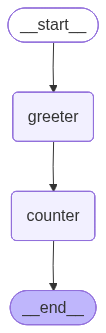

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
result = app.invoke({'message': 'Bibbidy Bob', 'count': 0})

In [22]:
result['message']

"Howdy Bibbidy Bob, how's she goin'?"

In [21]:
result['count']

1